/var/folders/6g/b8fqkdb93753h_gq88s28bf00000gn/T/ipykernel_22379/1274807080.py:17: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


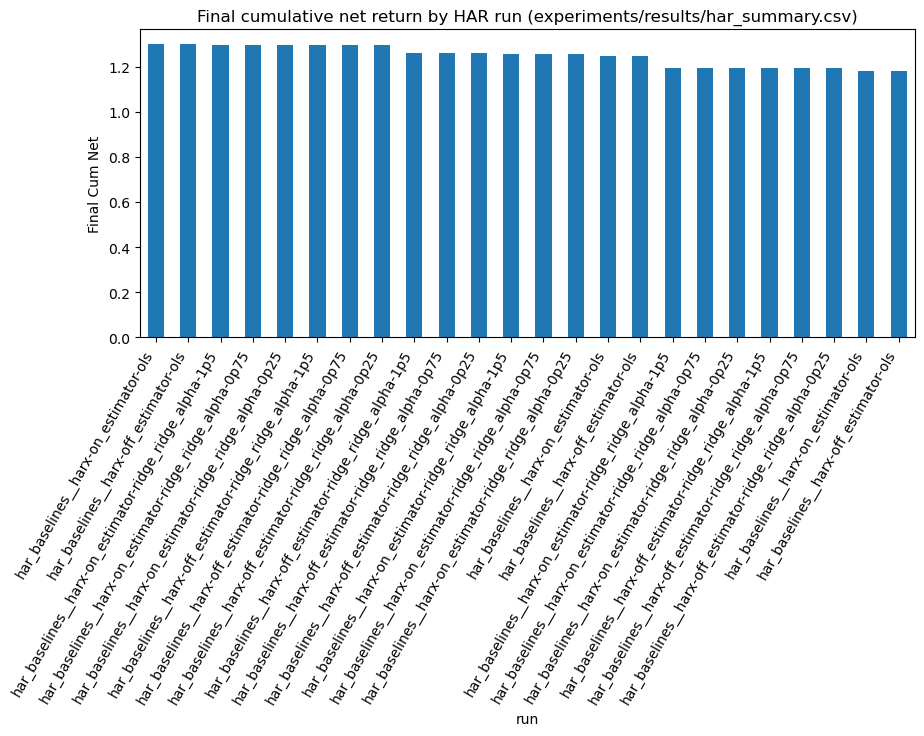

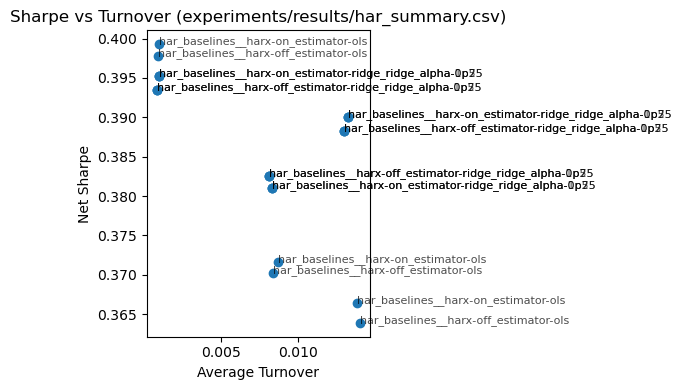

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("/Users/sonalilonkar/Desktop/Projects/DL_Project/vol-forecasting/experiments/results/har_summary.csv")

fig, ax = plt.subplots(figsize=(10,4))
df.sort_values("final_cum_net", ascending=False).plot.bar(
    x="run",
    y="final_cum_net",
    ax=ax,
    legend=False,
    title="Final cumulative net return by HAR run (experiments/results/har_summary.csv)",
)
ax.set_ylabel("Final Cum Net")
plt.xticks(rotation=60, ha="right")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(6,4))
ax.scatter(df["avg_turnover"], df["sharpe_net"])
for _, row in df.iterrows():
    ax.annotate(row["run"], (row["avg_turnover"], row["sharpe_net"]), fontsize=8, alpha=0.7)
ax.set_xlabel("Average Turnover")
ax.set_ylabel("Net Sharpe")
ax.set_title("Sharpe vs Turnover (experiments/results/har_summary.csv)")
plt.tight_layout()
plt.show()

The first bar chart ranks every HAR baseline by final cumulative net return (values pulled from `experiments/results/har_summary.csv`). The tallest bars belong to the HARX variants using OLS or Ridge on the 1-day horizon—specifically `har_baselines__harx-on_estimator-ols` and `harx-off_estimator-ols`, both ending around 1.30× cumulative net over the 2020‑24 test window. Ridge with HARX is only a hair behind at 1.296×.

The scatter plot (Sharpe vs. turnover) shows the same story from a risk-adjusted lens: the points with the highest Sharpe (~0.40) sit near the left edge (<0.001 turnover), corresponding to the HARX OLS runs at H=1. All other variants cluster slightly lower in Sharpe and, for H=5 and H=22, further to the right (higher turnover).

So, if you need a single “best” HAR baseline, HARX with OLS at the 1-day horizon delivers both the highest final cumulative net and the top Sharpe while keeping turnover essentially zero.

In [ ]:
from argparse import Namespace
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

if 'other_experiment_tables' in globals():
    del other_experiment_tables  # stale cache between runs


def find_repo_root(marker: str = "configs/experiment_plan.yaml") -> Path:
    here = Path.cwd()
    for candidate in [here, *here.parents]:
        if (candidate / marker).exists():
            return candidate
    raise RuntimeError("Could not locate project root from current working directory.")


REPO_ROOT = find_repo_root()
SUMMARY_PATH = REPO_ROOT / "experiments" / "results" / "automation_summary.csv"
if not SUMMARY_PATH.exists():
    raise FileNotFoundError(f"Missing automation summary: {SUMMARY_PATH}")

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from scripts import summarize_experiments as summarize_mod  # noqa: E402

summary_index = pd.read_csv(SUMMARY_PATH)
other_experiments = [exp for exp in sorted(summary_index["experiment"].unique()) if exp != "har_baselines"]
other_experiment_tables = {}

if not other_experiments:
    print("No non-HAR experiments recorded yet; rerun after additional batches finish.")
else:
    for experiment_name in other_experiments:
        args = Namespace(
            summary=Path("experiments/results/automation_summary.csv"),
            experiments=[experiment_name],
            sort_by="final_cum_net",
        )
        exp_df = summarize_mod.aggregate(args)
        other_experiment_tables[experiment_name] = exp_df
        out_path = REPO_ROOT / "experiments" / "results" / f"{experiment_name}_summary.csv"
        exp_df.to_csv(out_path, index=False)

        fig, axes = plt.subplots(1, 2, figsize=(12, 4))
        exp_df.sort_values("final_cum_net", ascending=False).plot.bar(
            x="run",
            y="final_cum_net",
            ax=axes[0],
            legend=False,
            title=f"{experiment_name}: Final cumulative net",
        )
        axes[0].set_ylabel("Final Cum Net")
        axes[0].tick_params(axis="x", rotation=60, labelsize=8)

        axes[1].scatter(exp_df["avg_turnover"], exp_df["sharpe_net"], s=35, alpha=0.8)
        for _, row in exp_df.iterrows():
            if pd.notna(row["avg_turnover"]) and pd.notna(row["sharpe_net"]):
                axes[1].annotate(
                    row["run"],
                    (row["avg_turnover"], row["sharpe_net"]),
                    fontsize=7,
                    alpha=0.7,
                )
        axes[1].set_xlabel("Average Turnover")
        axes[1].set_ylabel("Net Sharpe")
        axes[1].set_title(f"{experiment_name}: Sharpe vs Turnover")

        fig.suptitle(f"{experiment_name} backtest snapshot ({out_path.name})")
        fig.tight_layout()
        plt.show()


In [ ]:
from IPython.display import Markdown

analysis_lines = []
if "other_experiment_tables" not in globals() or not other_experiment_tables:
    analysis_lines.append(
        "No non-HAR experiments have completed yet, so re-run this notebook cell once more backtests are ingested into `experiments/results/automation_summary.csv`."
    )
else:
    for experiment_name, table in other_experiment_tables.items():
        top_cum = table.loc[table["final_cum_net"].idxmax()]
        if table["sharpe_net"].notna().any():
            top_sharpe = table.loc[table["sharpe_net"].idxmax()]
        else:
            top_sharpe = top_cum
        cum_line = (
            f"`{top_cum['run']}` at H={int(top_cum['horizon'])} ends the test window at "
            f"{top_cum['final_cum_net']:.3f}× cumulative net and annualized CAGR {top_cum['net_cagr']:.3%}."
        )
        sharpe_line = (
            f"Highest risk-adjusted performance comes from `{top_sharpe['run']}` with Sharpe "
            f"{top_sharpe['sharpe_net']:.3f} and turnover {top_sharpe['avg_turnover']:.4f}."
            if pd.notna(top_sharpe["sharpe_net"]) and pd.notna(top_sharpe["avg_turnover"])
            else "Risk-adjusted stats are unavailable for this experiment (missing Sharpe or turnover columns)."
        )
        analysis_lines.append(
            f"**{experiment_name}** — {cum_line} {sharpe_line}"
        )

display(Markdown("\n\n".join(f"- {line}" for line in analysis_lines)))
